<a href="https://colab.research.google.com/github/msijewelsaif/MachineLearning/blob/main/Project/Fraud_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
np.random.seed(42)  # For reproducibility

In [3]:
# Generating features
data = {
    'Transaction_Amount': np.random.uniform(10, 500, 1000),  # Amounts between $10 and $500
    'Transaction_Time': np.random.randint(0, 24, 1000),  # Hours of the day
    'Transaction_Location': np.random.randint(1, 50, 1000),  # City codes (1 to 50)
}


In [4]:
# Generating labels with some logic for fraudulent activity
# Higher amounts at odd hours have a higher chance of being fraudulent
fraud_probability = (
    (data['Transaction_Amount'] > 400).astype(int) +
    ((data['Transaction_Time'] < 6) | (data['Transaction_Time'] > 22)).astype(int)
)

In [5]:
data['Fraudulent'] = (np.random.rand(1000) < fraud_probability / 3).astype(int)

In [6]:
# Converting to a DataFrame
df = pd.DataFrame(data)

In [7]:
# 2. Preprocessing data
X = df[['Transaction_Amount', 'Transaction_Time', 'Transaction_Location']]
y = df['Fraudulent']

In [8]:
# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
# 3. Building the Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [10]:
# 4. Evaluating the Model
# Predictions
y_pred = model.predict(X_test)

In [11]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.88

Confusion Matrix:
[[258   4]
 [ 33   5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       262
           1       0.56      0.13      0.21        38

    accuracy                           0.88       300
   macro avg       0.72      0.56      0.57       300
weighted avg       0.84      0.88      0.84       300



In [19]:
# 5. Making Predictions on New Transactions
new_transactions = pd.DataFrame({
    'Transaction_Amount': [450, 521, 400],
    'Transaction_Time': [23, 12, 3],
    'Transaction_Location': [10, 35, 12]
})

new_predictions = model.predict(new_transactions)
for i, pred in enumerate(new_predictions):
    print(f"Transaction {i+1} -> {'Fraudulent' if pred == 1 else 'Not Fraudulent'}")


Transaction 1 -> Not Fraudulent
Transaction 2 -> Not Fraudulent
Transaction 3 -> Not Fraudulent


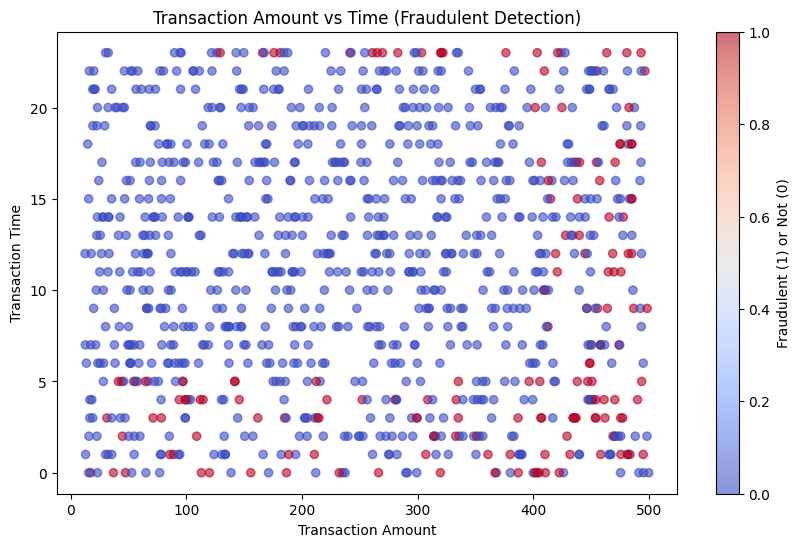

In [13]:
# 6. Visualizing Results (Optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['Transaction_Amount'], df['Transaction_Time'], c=df['Fraudulent'], cmap='coolwarm', alpha=0.6)
plt.colorbar(label='Fraudulent (1) or Not (0)')
plt.title("Transaction Amount vs Time (Fraudulent Detection)")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Time")
plt.show()